# RiskHunter — Mapping Pipeline · Sandbox

Notebook **auto-contenu** : toute la logique du pipeline est ici, sans dépendance sur le package `referential_mapping`.  
Modifie directement les cellules pour tester / ajuster la logique.

| Étape | Description |
|-------|-------------|
| **0** | Imports & configuration |
| **1** | Modèles de données |
| **2** | Adaptateur YAML universel |
| **3** | Chargement des référentiels |
| **4** | Similarité sémantique (embeddings) |
| **5** | Matrice de corrélation (heatmap) |
| **6** | LLM scoring (étape 4) |
| **7** | Export Excel |
| **8** | Diagnostics & analyse |

## 0 — Imports & Configuration

In [16]:
%matplotlib inline
import re, json, os, asyncio
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Literal

# ─── Chemins ────────────────────────────────────────────────────────────────
ROOT        = Path(".")                        # racine du projet
SURVEYS_DIR = ROOT / "files" / "surveys"       # dossier des YAMLs
DATA_DIR    = ROOT / "referential_mapping" / "data"
OUTPUT_DIR  = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ─── Paramètres pipeline ─────────────────────────────────────────────────────
EMBEDDING_MODEL      = "all-MiniLM-L6-v2"  # modèle sentence-transformers local
SEMANTIC_THRESHOLD   = 0.40   # score cosinus min pour conserver une paire
TOP_K                = 5      # nb candidats Ref B max par exigence Ref A

# ─── Paramètres LLM ──────────────────────────────────────────────────────────
LLM_MODEL            = "gpt-4o-mini"
LLM_MAX_RETRIES      = 2
LLM_CONFIRM_THRESHOLD = 0.75  # seuil pour déclencher la double vérification
LLM_CONCURRENCY      = 5

print(f"✅ Config chargée — surveys: {SURVEYS_DIR}")

✅ Config chargée — surveys: files\surveys


## 1 — Modèles de données

In [17]:
@dataclass
class RequirementNormalized:
    """Une exigence normalisée issue d'un référentiel."""
    id: str            # ex. "CIS-1.1" | "GV.OC-01"
    framework: str     # ex. "cis_controls_v8"
    title: str         # champ principal — étapes 2 & 3
    description: str   # utilisé à l'étape 4 uniquement
    tags: list = field(default_factory=list)

    def to_dict(self) -> dict:
        return {"id": self.id, "framework": self.framework,
                "title": self.title, "description": self.description, "tags": self.tags}

    @staticmethod
    def from_dict(d: dict) -> "RequirementNormalized":
        return RequirementNormalized(
            id=d["id"], framework=d["framework"],
            title=d["title"], description=d.get("description", ""),
            tags=d.get("tags", []))


@dataclass
class CandidatePair:
    """Paire candidate issue de la recherche sémantique."""
    id_A: str
    title_A: str
    id_B: str
    title_B: str
    semantic_score: float

    def to_dict(self):
        return {"id_A": self.id_A, "title_A": self.title_A,
                "id_B": self.id_B, "title_B": self.title_B,
                "semantic_score": round(self.semantic_score, 4)}


@dataclass
class MappingRelation:
    """Relation de mapping validée par le LLM."""
    id_A: str
    title_A: str
    id_B: str
    title_B: str
    semantic_score: float
    coverage_A_to_B: float
    coverage_B_to_A: float
    confidence: float
    relation_type: str  # "equivalence"|"A_couvre_B"|"B_couvre_A"|"partielle"|"aucun_lien"

    def to_dict(self):
        return {"id_A": self.id_A, "title_A": self.title_A,
                "id_B": self.id_B, "title_B": self.title_B,
                "semantic_score": round(self.semantic_score, 4),
                "coverage_A_to_B": round(self.coverage_A_to_B, 4),
                "coverage_B_to_A": round(self.coverage_B_to_A, 4),
                "confidence": round(self.confidence, 4),
                "relation_type": self.relation_type}

print("✅ Modèles de données définis.")

✅ Modèles de données définis.


## 2 — Adaptateur YAML universel

In [18]:
def _clean_id(raw: str) -> str:
    return re.sub(r"[^\x00-\x7F]", "", raw).strip(". ")

def _clean_text(raw: str) -> str:
    return re.sub(r"\s+", " ", raw).strip()

def _name_from_path(path: Path) -> str:
    """cis-controls-v8-1.yaml → cis_controls_v8"""
    stem = re.sub(r"[-_]\d+$", "", path.stem)
    return stem.replace("-", "_").replace(" ", "_")

def _extract(
    node: dict,
    framework: str,
    id_prefix: str,
    parent_tags: list,
    requirements: list,
) -> None:
    """
    Extraction récursive des exigences depuis un nœud YAML.
    Supporte :
      - {n}_label / {n}_desc / {n}_prefix  (CIS, NIST, ISO …)
      - {n}_desc only (DORA) → desc utilisé comme titre
      - sous-sections entières récursives (PCI-DSS, NIS2 …)
    """
    # ── Exigences plates ─────────────────────────────────────────────────────
    all_nums = set()
    for k in node:
        if isinstance(k, str):
            parts = k.split("_")
            if len(parts) >= 2 and parts[0].isdigit() and parts[1] in ("label", "desc", "prefix"):
                all_nums.add(int(parts[0]))

    for n in sorted(all_nums):
        label  = str(node.get(f"{n}_label",  "")).strip()
        desc   = str(node.get(f"{n}_desc",   "")).strip()
        prefix = str(node.get(f"{n}_prefix", "")).strip()

        # Fallback : pas de label → on utilise les 120 premiers chars du desc
        if not label and desc:
            label = desc[:120].rstrip() + ("…" if len(desc) > 120 else "")
            desc  = ""

        if not label:
            continue

        req_id = _clean_id(prefix if prefix else f"{id_prefix}.{n}")
        requirements.append(RequirementNormalized(
            id=req_id, framework=framework,
            title=_clean_text(label), description=_clean_text(desc),
            tags=parent_tags.copy(),
        ))

    # ── Sous-sections récursives ─────────────────────────────────────────────
    for sub_num in sorted(k for k in node if isinstance(k, int)):
        sub = node[sub_num]
        if not isinstance(sub, dict):
            continue
        sub_title  = str(sub.get("title",  "")).strip()
        sub_prefix = str(sub.get("prefix", "")).strip()
        sub_id = sub_prefix if sub_prefix else f"{id_prefix}.{sub_num}"
        _extract(
            node=sub, framework=framework,
            id_prefix=sub_id,
            parent_tags=parent_tags + ([sub_title] if sub_title else []),
            requirements=requirements,
        )


def load_yaml_framework(path, framework_name=None) -> list:
    """Parse n'importe quel YAML de référentiel → liste de RequirementNormalized."""
    path = Path(path)
    framework = framework_name or _name_from_path(path)
    with open(path, encoding="utf-8") as f:
        data = yaml.safe_load(f)
    requirements = []
    for section_num, section in data.items():
        if not isinstance(section, dict):
            continue
        section_title  = str(section.get("title",  "")).strip()
        section_prefix = str(section.get("prefix", "")).strip()
        _extract(
            node=section, framework=framework,
            id_prefix=section_prefix or str(section_num),
            parent_tags=[section_title] if section_title else [],
            requirements=requirements,
        )
    return requirements


def list_frameworks(surveys_dir=None) -> dict:
    """Découvre tous les YAMLs dans files/surveys/ → {nom: Path}."""
    d = Path(surveys_dir or SURVEYS_DIR)
    return {
        _name_from_path(p): p
        for p in sorted(d.rglob("*.yaml"))
        if "__MACOSX" not in str(p)
    }


# ── Test rapide ───────────────────────────────────────────────────────────────
frameworks = list_frameworks()
print(f"✅ {len(frameworks)} référentiels découverts :")
for name in sorted(frameworks):
    print(f"   {name}")

✅ 41 référentiels découverts :
   5_20Law
   afnor_spec
   ai_act
   ansm
   anssiAISecurity
   anssiHygieneGuideV2
   cis_controls_v8
   cosmetovigilance
   dora
   ecc1
   eumdr
   fda_cfr_21_part
   hdsV2
   ichE6R2
   iec_62443_3_2
   igi1300
   ii901
   isa6_0_3_tisax
   iso13485
   iso14001
   iso17021
   iso17024
   iso20000
   iso20022_1
   iso20022_2
   iso26000
   iso27001
   iso27701
   iso42001
   iso50001
   iso9001
   nis2
   nis2v2
   nistCsfV2
   owaspV4_0
   owasp_llm_ai_v1
   pcidssV4
   qualiopiV9
   rgpdCnil
   secnumcloud_v3
   soc2_type2


## 3 — Chargement des référentiels

> Modifie `REF_A` et `REF_B` pour tester d'autres paires.

In [19]:
# ─── Choix des référentiels ──────────────────────────────────────────────────
REF_A = "cis_controls_v8"   # ← modifier ici
REF_B = "nistCsfV2"          # ← modifier ici

assert REF_A in frameworks, f"'{REF_A}' introuvable. Disponibles : {list(frameworks)}"
assert REF_B in frameworks, f"'{REF_B}' introuvable. Disponibles : {list(frameworks)}"
assert REF_A != REF_B, "Choisis deux référentiels différents."

ref_A = load_yaml_framework(frameworks[REF_A], framework_name=REF_A)
ref_B = load_yaml_framework(frameworks[REF_B], framework_name=REF_B)

print(f"\n✅ Étape 1 — Parsing terminé")
print(f"   {REF_A} : {len(ref_A)} exigences")
print(f"   {REF_B} : {len(ref_B)} exigences")
print(f"   Combinaisons totales : {len(ref_A) * len(ref_B):,}")

# Aperçu
print(f"\n--- Aperçu {REF_A} (5 premières) ---")
for r in ref_A[:5]:
    print(f"  [{r.id}] {r.title[:80]}")
print(f"\n--- Aperçu {REF_B} (5 premières) ---")
for r in ref_B[:5]:
    print(f"  [{r.id}] {r.title[:80]}")


✅ Étape 1 — Parsing terminé
   cis_controls_v8 : 153 exigences
   nistCsfV2 : 106 exigences
   Combinaisons totales : 16,218

--- Aperçu cis_controls_v8 (5 premières) ---
  [1.1] Établir et tenir à jour un inventaire détaillé des actifs de l'entreprise
  [1.2] Lutte contre les actifs non autorisés
  [1.3] Utiliser un outil de découverte active
  [1.4] Utiliser le protocole de configuration dynamique de l'hôte (DHCP) pour mettre à 
  [1.5] Utiliser un outil de découverte d'actifs passifs

--- Aperçu nistCsfV2 (5 premières) ---
  [GV.OC-01] La mission organisationnelle est comprise et oriente la gestion des risques de c
  [GV.OC-02] Les parties prenantes internes et externes sont comprises, et leurs besoins et a
  [GV.OC-03] Les exigences légales, réglementaires et contractuelles concernant la cybersécur
  [GV.OC-04] Les objectifs, capacités et services critiques dont dépendent les parties prenan
  [GV.OC-05] Les résultats, capacités et services dont dépend l'organisation sont compris e

## 4 — Étape 2 : Similarité sémantique (embeddings sur les titres)

In [20]:
from sentence_transformers import SentenceTransformer

FORCE_RECOMPUTE = False   # ← True pour recalculer même si le cache existe

CACHE_PAIRS  = DATA_DIR / "candidate_pairs.json"
CACHE_MATRIX = DATA_DIR / "similarity_matrix.npy"

def compute_similarity(ref_A, ref_B, model_name=EMBEDDING_MODEL):
    """Encode les titres et retourne la matrice cosinus (n_A × n_B)."""
    model = SentenceTransformer(model_name)
    print(f"  Encodage de {len(ref_A)} titres A ...")
    emb_A = model.encode([r.title for r in ref_A], show_progress_bar=True, convert_to_numpy=True)
    print(f"  Encodage de {len(ref_B)} titres B ...")
    emb_B = model.encode([r.title for r in ref_B], show_progress_bar=True, convert_to_numpy=True)
    # L2-normalisation → produit scalaire == cosinus
    emb_A /= np.linalg.norm(emb_A, axis=1, keepdims=True)
    emb_B /= np.linalg.norm(emb_B, axis=1, keepdims=True)
    return emb_A @ emb_B.T   # shape (n_A, n_B)


def select_pairs(ref_A, ref_B, matrix, threshold=SEMANTIC_THRESHOLD, top_k=TOP_K):
    """Retourne les paires candidates (top-k par exigence A ET score >= seuil)."""
    pairs, seen = [], set()
    for i, req_a in enumerate(ref_A):
        scores = matrix[i]
        top_idx = np.argsort(scores)[::-1][:top_k]
        for j in top_idx:
            score = float(scores[j])
            if score < threshold:
                break
            key = (req_a.id, ref_B[j].id)
            if key not in seen:
                seen.add(key)
                pairs.append(CandidatePair(
                    id_A=req_a.id, title_A=req_a.title,
                    id_B=ref_B[j].id, title_B=ref_B[j].title,
                    semantic_score=score,
                ))
    pairs.sort(key=lambda p: p.semantic_score, reverse=True)
    return pairs


# ── Calcul ou cache ───────────────────────────────────────────────────────────
if CACHE_PAIRS.exists() and CACHE_MATRIX.exists() and not FORCE_RECOMPUTE:
    print("[Étape 2] Cache trouvé — rechargement ...")
    with open(CACHE_PAIRS) as f:
        candidate_pairs = [CandidatePair(**d) for d in json.load(f)]
    similarity_matrix = np.load(str(CACHE_MATRIX))
else:
    print("[Étape 2] Calcul de la matrice de similarité ...")
    similarity_matrix = compute_similarity(ref_A, ref_B)
    candidate_pairs   = select_pairs(ref_A, ref_B, similarity_matrix)
    # Sauvegarder le cache
    np.save(str(CACHE_MATRIX), similarity_matrix)
    CACHE_PAIRS.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE_PAIRS, "w", encoding="utf-8") as f:
        json.dump([p.to_dict() for p in candidate_pairs], f, ensure_ascii=False, indent=2)

total_combos = len(ref_A) * len(ref_B)
print(f"\n✅ Étape 2 terminée")
print(f"   {total_combos:,} combinaisons → {len(candidate_pairs)} paires candidates")
print(f"   Réduction : {100 * len(candidate_pairs) / total_combos:.2f}% conservé")
print(f"   Score max : {candidate_pairs[0].semantic_score:.4f} | min : {candidate_pairs[-1].semantic_score:.4f}")

[Étape 2] Cache trouvé — rechargement ...

✅ Étape 2 terminée
   16,218 combinaisons → 721 paires candidates
   Réduction : 4.45% conservé
   Score max : 0.8690 | min : 0.4009


In [21]:
# ── Afficher le top-20 des paires ─────────────────────────────────────────────
df_pairs = pd.DataFrame([p.to_dict() for p in candidate_pairs])
print(f"Top 20 paires candidates (score cosinus décroissant) :\n")
display(df_pairs.head(20)[["id_A", "title_A", "id_B", "title_B", "semantic_score"]])

Top 20 paires candidates (score cosinus décroissant) :



,id_A,title_A,id_B,title_B,semantic_score
0,CIS-7.1,Ã‰tablir et maintenir un processus de gestion ...,ID.RA-08,"Des processus pour recevoir, analyser et rÃ©po...",0.8690
1,CIS-17.4,Ã‰tablir et maintenir un processus de rÃ©ponse...,RC.RP-01,La partie rÃ©cupÃ©ration du plan de rÃ©ponse a...,0.8481
2,CIS-8.12,Collecter les journaux des fournisseurs de ser...,ID.AM-04,Les inventaires des services fournis par les f...,0.8063
3,CIS-2.3,Lutter contre les logiciels non autorisÃ©s,PR.PS-05,L'installation et l'exÃ©cution de logiciels no...,0.7969
4,CIS-2.1,Ã‰tablir et maintenir un inventaire des logiciels,ID.AM-02,"Les inventaires des logiciels, services et sys...",0.7537
5,CIS-17.9,Ã‰tablir et maintenir des seuils d'incidents d...,RS.MI-02,Les incidents sont Ã©radiquÃ©s,0.7511
6,CIS-17.7,Effectuer des exercices de routine de rÃ©ponse...,RC.RP-01,La partie rÃ©cupÃ©ration du plan de rÃ©ponse a...,0.7486
7,CIS-17.4,Ã‰tablir et maintenir un processus de rÃ©ponse...,ID.RA-08,"Des processus pour recevoir, analyser et rÃ©po...",0.7483
8,CIS-15.7,DÃ©classer les fournisseurs de services en tou...,ID.AM-04,Les inventaires des services fournis par les f...,0.7426
9,CIS-16.4,Ã‰tablir et gÃ©rer un inventaire des composant...,ID.AM-02,"Les inventaires des logiciels, services et sys...",0.7337


## 5 — Étape 3 : Matrice de corrélation (heatmap)

  Heatmap sauvegardée → referential_mapping\data\outputs\correlation_matrix.png


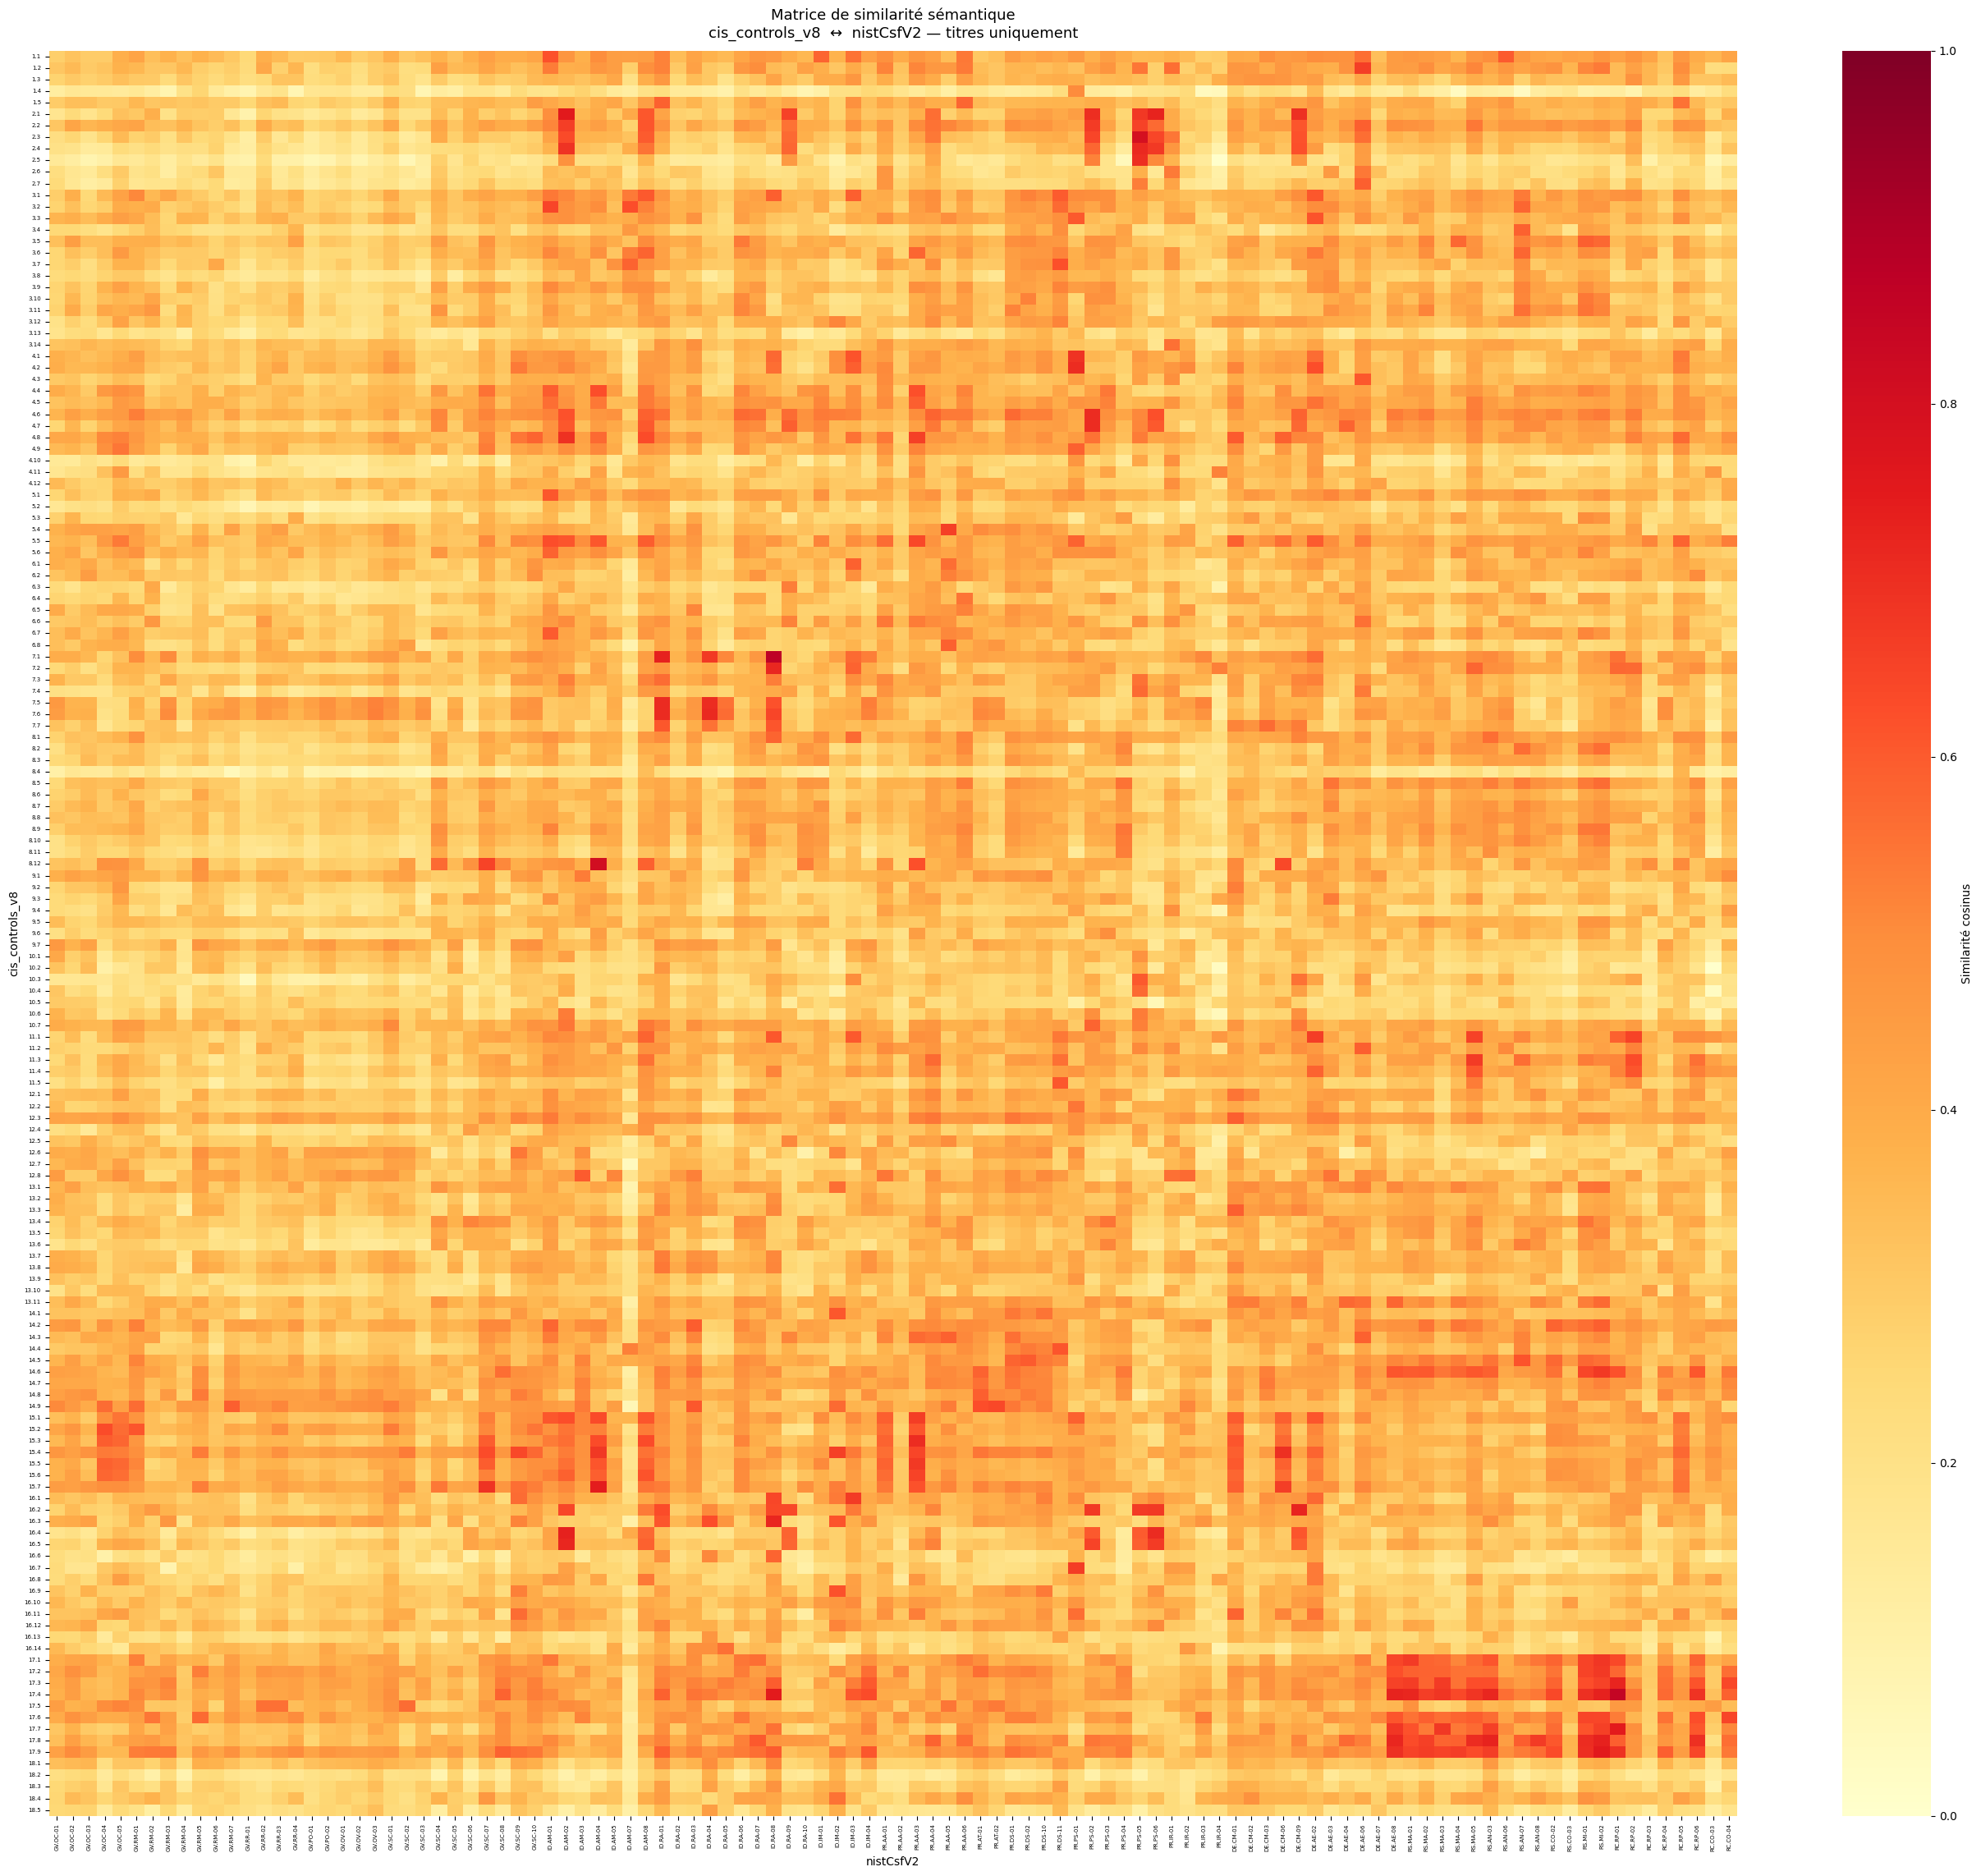

In [22]:
def plot_heatmap(ref_A, ref_B, matrix, title="Matrice de similarité sémantique",
                 cmap="YlOrRd", save_path=None):
    """Génère et affiche la heatmap de corrélation."""
    labels_A = [r.id for r in ref_A]
    labels_B = [r.id for r in ref_B]

    fig_w = max(20, len(labels_B) * 0.25)
    fig_h = max(14, len(labels_A) * 0.15)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(matrix,
                xticklabels=labels_B,
                yticklabels=labels_A,
                cmap=cmap,
                vmin=0, vmax=1, ax=ax,
                linewidths=0,
                cbar_kws={"label": "Similarité cosinus"})
    ax.set_title(f"{title}\n{REF_A}  ↔  {REF_B} — titres uniquement", fontsize=13, pad=12)
    ax.set_xlabel(REF_B, fontsize=10)
    ax.set_ylabel(REF_A, fontsize=10)
    ax.tick_params(axis="x", labelsize=5, rotation=90)
    ax.tick_params(axis="y", labelsize=5)
    plt.tight_layout()

    if save_path:
        plt.savefig(str(save_path), dpi=150, bbox_inches="tight")
        print(f"  Heatmap sauvegardée → {save_path}")
    plt.show()


heatmap_path = OUTPUT_DIR / "correlation_matrix.png"
plot_heatmap(ref_A, ref_B, similarity_matrix, save_path=heatmap_path)

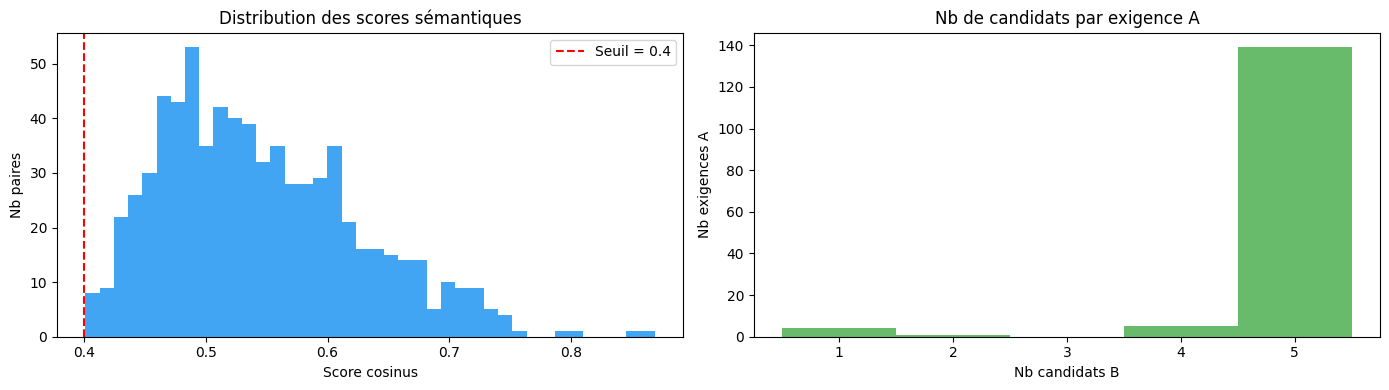

Exigences A avec au moins 1 candidat : 149 / 153 (97.4%)
Exigences A sans candidat (score < 0.4) : 4


In [23]:
# ── Distribution des scores des paires candidates ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

scores = df_pairs["semantic_score"]
axes[0].hist(scores, bins=40, color="#2196F3", edgecolor="none", alpha=0.85)
axes[0].axvline(SEMANTIC_THRESHOLD, color="red", linestyle="--", label=f"Seuil = {SEMANTIC_THRESHOLD}")
axes[0].set_title("Distribution des scores sémantiques")
axes[0].set_xlabel("Score cosinus")
axes[0].set_ylabel("Nb paires")
axes[0].legend()

# Nb de candidats par exigence A
counts = df_pairs.groupby("id_A").size()
axes[1].hist(counts, bins=range(1, TOP_K + 2), color="#4CAF50", edgecolor="none", alpha=0.85, align="left")
axes[1].set_title("Nb de candidats par exigence A")
axes[1].set_xlabel("Nb candidats B")
axes[1].set_ylabel("Nb exigences A")
axes[1].set_xticks(range(1, TOP_K + 1))

plt.tight_layout()
plt.show()

# Stats
print(f"Exigences A avec au moins 1 candidat : {counts.shape[0]} / {len(ref_A)} "
      f"({100*counts.shape[0]/len(ref_A):.1f}%)")
print(f"Exigences A sans candidat (score < {SEMANTIC_THRESHOLD}) : "
      f"{len(ref_A) - counts.shape[0]}")

## 6 — Étape 4 : Vérification LLM

> **Prérequis** : définir la variable d'environnement `OPENAI_API_KEY`  
> `import os; os.environ['OPENAI_API_KEY'] = 'sk-...'`
>
> Mettre `ENABLE_LLM = True` pour activer le scoring.

In [24]:
ENABLE_LLM   = False   # ← True pour activer (nécessite OPENAI_API_KEY)
FORCE_LLM    = False   # ← True pour recalculer même si le cache existe
CACHE_RELATIONS = OUTPUT_DIR / "mapping_relations.json"

SYSTEM_PROMPT = """Tu es un expert en référentiels de cybersécurité et conformité.
Tu dois évaluer la corrélation entre deux exigences issues de référentiels différents.
Réponds UNIQUEMENT en JSON valide, sans commentaire, avec exactement ces clés :
- coverage_A_to_B (float 0-1) : dans quelle mesure A couvre/satisfait B
- coverage_B_to_A (float 0-1) : dans quelle mesure B couvre/satisfait A
- confidence (float 0-1) : ta confiance dans cette évaluation
- relation_type : exactement l'une de ces valeurs :
  "equivalence" | "A_couvre_B" | "B_couvre_A" | "partielle" | "aucun_lien"

Règles pour relation_type :
- equivalence  : coverage_A_to_B >= 0.8 ET coverage_B_to_A >= 0.8
- A_couvre_B   : coverage_A_to_B >= 0.8 ET coverage_B_to_A < 0.8
- B_couvre_A   : coverage_B_to_A >= 0.8 ET coverage_A_to_B < 0.8
- partielle    : coverage_A_to_B >= 0.4 OU coverage_B_to_A >= 0.4
- aucun_lien   : sinon"""

def _make_prompt(req_a, req_b):
    return (
        f"Exigence A ({req_a.framework}) :\n"
        f"Titre : {req_a.title}\n"
        f"Description : {req_a.description or '(non disponible)'}\n\n"
        f"Exigence B ({req_b.framework}) :\n"
        f"Titre : {req_b.title}\n"
        f"Description : {req_b.description or '(non disponible)'}\n\n"
        f"Évalue la corrélation entre ces deux exigences."
    )


async def _score_pair(client, semaphore, req_a, req_b, model=LLM_MODEL, retries=LLM_MAX_RETRIES):
    async with semaphore:
        for attempt in range(retries + 1):
            try:
                resp = await client.chat.completions.create(
                    model=model,
                    response_format={"type": "json_object"},
                    messages=[
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user",   "content": _make_prompt(req_a, req_b)},
                    ],
                    temperature=0.0,
                )
                raw = resp.choices[0].message.content
                data = json.loads(raw)
                # Validation manuelle (sans pydantic)
                assert all(k in data for k in ("coverage_A_to_B", "coverage_B_to_A", "confidence", "relation_type"))
                assert data["relation_type"] in ("equivalence", "A_couvre_B", "B_couvre_A", "partielle", "aucun_lien")
                return data
            except Exception as e:
                if attempt == retries:
                    print(f"  [LLM ERREUR] {req_a.id}↔{req_b.id} : {e}")
                    return None
    return None


async def run_llm_scoring(candidates, ref_A, ref_B):
    from openai import AsyncOpenAI
    client    = AsyncOpenAI(api_key=os.environ.get("OPENAI_API_KEY", ""))
    semaphore = asyncio.Semaphore(LLM_CONCURRENCY)
    ref_A_map = {r.id: r for r in ref_A}
    ref_B_map = {r.id: r for r in ref_B}

    print(f"[Étape 4] Scoring LLM sur {len(candidates)} paires ...")
    tasks   = [_score_pair(client, semaphore, ref_A_map[p.id_A], ref_B_map[p.id_B]) for p in candidates]
    results = await asyncio.gather(*tasks)

    relations = []
    for pair, res in zip(candidates, results):
        if res is None:
            continue
        relations.append(MappingRelation(
            id_A=pair.id_A, title_A=pair.title_A,
            id_B=pair.id_B, title_B=pair.title_B,
            semantic_score=pair.semantic_score,
            coverage_A_to_B=res["coverage_A_to_B"],
            coverage_B_to_A=res["coverage_B_to_A"],
            confidence=res["confidence"],
            relation_type=res["relation_type"],
        ))

    # Double vérification sur les paires à fort score
    high_score = [r for r in relations
                  if r.coverage_A_to_B >= LLM_CONFIRM_THRESHOLD
                  or r.coverage_B_to_A >= LLM_CONFIRM_THRESHOLD]
    if high_score:
        print(f"  Double vérification sur {len(high_score)} paires à fort score ...")
        confirm_tasks   = [_score_pair(client, semaphore, ref_A_map[r.id_A], ref_B_map[r.id_B]) for r in high_score]
        confirm_results = await asyncio.gather(*confirm_tasks)
        for rel, confirm in zip(high_score, confirm_results):
            if confirm is None:
                continue
            rel.coverage_A_to_B = round((rel.coverage_A_to_B + confirm["coverage_A_to_B"]) / 2, 4)
            rel.coverage_B_to_A = round((rel.coverage_B_to_A + confirm["coverage_B_to_A"]) / 2, 4)
            rel.confidence       = round((rel.confidence + confirm["confidence"]) / 2, 4)

    return relations


print("✅ Fonctions LLM définies.")
print(f"   ENABLE_LLM = {ENABLE_LLM}")

✅ Fonctions LLM définies.
   ENABLE_LLM = False


In [25]:
if not ENABLE_LLM:
    print("⏭️  LLM désactivé (ENABLE_LLM=False) — passage à l'export sémantique.")
    mapping_relations = None

elif CACHE_RELATIONS.exists() and not FORCE_LLM:
    print("[Étape 4] Cache trouvé — rechargement des relations.")
    with open(CACHE_RELATIONS) as f:
        mapping_relations = [MappingRelation(**d) for d in json.load(f)]
    print(f"  {len(mapping_relations)} relations chargées.")

else:
    # Jupyter nécessite nest_asyncio pour asyncio.run() dans une cellule
    try:
        import nest_asyncio; nest_asyncio.apply()
    except ImportError:
        pass

    mapping_relations = asyncio.run(run_llm_scoring(candidate_pairs, ref_A, ref_B))

    # Cache
    with open(CACHE_RELATIONS, "w", encoding="utf-8") as f:
        json.dump([r.to_dict() for r in mapping_relations], f, ensure_ascii=False, indent=2)
    print(f"\n✅ Étape 4 terminée — {len(mapping_relations)} relations scorées.")

⏭️  LLM désactivé (ENABLE_LLM=False) — passage à l'export sémantique.


## 7 — Export Excel

In [26]:
def export_excel(relations, ref_A_name, ref_B_name, output_dir=OUTPUT_DIR):
    """Exporte les résultats de mapping dans un fichier Excel coloré."""
    import openpyxl
    from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
    from openpyxl.utils import get_column_letter

    RELATION_COLORS = {
        "equivalence": "C6EFCE",  # vert
        "A_couvre_B":  "FFEB9C",  # jaune
        "B_couvre_A":  "FFEB9C",
        "partielle":   "FFDDC1",  # orange
        "aucun_lien":  "FFC7CE",  # rouge
    }
    thin   = Side(style="thin", color="CCCCCC")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = f"{ref_A_name[:12]} ↔ {ref_B_name[:12]}"

    headers = ["ID Ref A", "Titre Ref A", "ID Ref B", "Titre Ref B",
               "Score sémantique", "Coverage A→B", "Coverage B→A",
               "Confiance", "Type de relation"]

    for col, h in enumerate(headers, 1):
        cell = ws.cell(row=1, column=col, value=h)
        cell.fill = PatternFill("solid", fgColor="1F4E79")
        cell.font = Font(bold=True, color="FFFFFF")
        cell.alignment = Alignment(horizontal="center", wrap_text=True)
        cell.border = border

    for row_idx, r in enumerate(relations, 2):
        vals = [r.id_A, r.title_A, r.id_B, r.title_B,
                r.semantic_score, r.coverage_A_to_B, r.coverage_B_to_A,
                r.confidence, r.relation_type]
        fill = PatternFill("solid", fgColor=RELATION_COLORS.get(r.relation_type, "FFFFFF"))
        for col_idx, val in enumerate(vals, 1):
            cell = ws.cell(row=row_idx, column=col_idx, value=val)
            cell.border = border
            cell.alignment = Alignment(wrap_text=True, vertical="top")
            if col_idx in (5, 6, 7, 8):
                cell.number_format = "0.000"
            if col_idx == 9:
                cell.fill = fill

    for i, w in enumerate([12, 50, 16, 50, 14, 12, 12, 10, 18], 1):
        ws.column_dimensions[get_column_letter(i)].width = w

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

    out = output_dir / f"mapping_{ref_A_name}_x_{ref_B_name}.xlsx"
    wb.save(str(out))
    return out


def export_semantic_excel(candidate_pairs, ref_A_name, ref_B_name, output_dir=OUTPUT_DIR):
    """Export Excel des paires sémantiques seules (sans LLM)."""
    import openpyxl
    from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
    from openpyxl.utils import get_column_letter
    from openpyxl.styles.differential import DifferentialStyle
    from openpyxl.formatting.rule import ColorScaleRule

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Paires sémantiques"
    thin   = Side(style="thin", color="CCCCCC")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    headers = ["ID Ref A", "Titre Ref A", "ID Ref B", "Titre Ref B", "Score sémantique"]
    for col, h in enumerate(headers, 1):
        cell = ws.cell(row=1, column=col, value=h)
        cell.fill = PatternFill("solid", fgColor="1F4E79")
        cell.font = Font(bold=True, color="FFFFFF")
        cell.alignment = Alignment(horizontal="center")
        cell.border = border

    for row_idx, p in enumerate(candidate_pairs, 2):
        vals = [p.id_A, p.title_A, p.id_B, p.title_B, p.semantic_score]
        for col_idx, val in enumerate(vals, 1):
            cell = ws.cell(row=row_idx, column=col_idx, value=val)
            cell.border = border
            if col_idx == 5:
                cell.number_format = "0.000"

    # Color scale sur la colonne Score
    last_row = len(candidate_pairs) + 1
    ws.conditional_formatting.add(
        f"E2:E{last_row}",
        ColorScaleRule(start_type="min", start_color="FFC7CE",
                       mid_type="percentile", mid_value=50, mid_color="FFEB9C",
                       end_type="max", end_color="C6EFCE")
    )

    for i, w in enumerate([12, 50, 16, 50, 14], 1):
        ws.column_dimensions[get_column_letter(i)].width = w

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

    out = output_dir / f"semantic_pairs_{ref_A_name}_x_{ref_B_name}.xlsx"
    wb.save(str(out))
    return out


# ── Lancer l'export ───────────────────────────────────────────────────────────
if mapping_relations is not None:
    out = export_excel(mapping_relations, REF_A, REF_B)
    print(f"✅ Export LLM → {out}")
else:
    out = export_semantic_excel(candidate_pairs, REF_A, REF_B)
    print(f"✅ Export sémantique → {out}")

✅ Export sémantique → referential_mapping\data\outputs\semantic_pairs_cis_controls_v8_x_nistCsfV2.xlsx


## 8 — Diagnostics & Analyse

In [27]:
print("=" * 70)
print(f" DIAGNOSTIC — {REF_A}  ↔  {REF_B}")
print("=" * 70)
print(f" Référentiel A : {len(ref_A):>4} exigences")
print(f" Référentiel B : {len(ref_B):>4} exigences")
print(f" Combinaisons  : {len(ref_A)*len(ref_B):>7,}")
print(f" Seuil cosinus : {SEMANTIC_THRESHOLD}  |  Top-K : {TOP_K}")
print(f" Paires retenues (étape 2) : {len(candidate_pairs):>5}  "
      f"({100*len(candidate_pairs)/(len(ref_A)*len(ref_B)):.2f}%)")

covered_A = df_pairs["id_A"].nunique()
covered_B = df_pairs["id_B"].nunique()
print(f" Exigences A couvertes     : {covered_A:>5} / {len(ref_A)} "
      f"({100*covered_A/len(ref_A):.1f}%)")
print(f" Exigences B couvertes     : {covered_B:>5} / {len(ref_B)} "
      f"({100*covered_B/len(ref_B):.1f}%)")

if mapping_relations is not None:
    print(f"\n Relations LLM scorées : {len(mapping_relations)}")
    for rt in ["equivalence", "A_couvre_B", "B_couvre_A", "partielle", "aucun_lien"]:
        n = sum(1 for r in mapping_relations if r.relation_type == rt)
        bar = "█" * n + "░" * (20 - min(n, 20))
        print(f"  {rt:20s} : {n:4d}  {bar}")
print("=" * 70)

 DIAGNOSTIC — cis_controls_v8  ↔  nistCsfV2
 Référentiel A :  153 exigences
 Référentiel B :  106 exigences
 Combinaisons  :  16,218
 Seuil cosinus : 0.4  |  Top-K : 5
 Paires retenues (étape 2) :   721  (4.45%)
 Exigences A couvertes     :   149 / 153 (97.4%)
 Exigences B couvertes     :    85 / 106 (80.2%)


In [28]:
# ── Top paires candidates (rapide lecture humaine) ────────────────────────────
print(f"\nTOP 30 PAIRES — {REF_A} ↔ {REF_B}\n")
print(f"{'Score':>6}  {'ID A':<15} {'Titre A':<45} {'ID B':<12} {'Titre B'}")
print("-" * 130)
for p in candidate_pairs[:30]:
    ta = p.title_A[:44].ljust(44)
    tb = p.title_B[:55]
    print(f"{p.semantic_score:>6.3f}  {p.id_A:<15} {ta}  {p.id_B:<12} {tb}")


TOP 30 PAIRES — cis_controls_v8 ↔ nistCsfV2

 Score  ID A            Titre A                                       ID B         Titre B
----------------------------------------------------------------------------------------------------------------------------------
 0.869  CIS-7.1         Ã‰tablir et maintenir un processus de gestio  ID.RA-08     Des processus pour recevoir, analyser et rÃ©pondre aux 
 0.848  CIS-17.4        Ã‰tablir et maintenir un processus de rÃ©pon  RC.RP-01     La partie rÃ©cupÃ©ration du plan de rÃ©ponse aux incide
 0.806  CIS-8.12        Collecter les journaux des fournisseurs de s  ID.AM-04     Les inventaires des services fournis par les fournisseu
 0.797  CIS-2.3         Lutter contre les logiciels non autorisÃ©s    PR.PS-05     L'installation et l'exÃ©cution de logiciels non autoris
 0.754  CIS-2.1         Ã‰tablir et maintenir un inventaire des logi  ID.AM-02     Les inventaires des logiciels, services et systÃ¨mes gÃ
 0.751  CIS-17.9        Ã‰tablir et m

In [29]:
# ── Exigences A sans aucune correspondance ────────────────────────────────────
covered_ids_A = set(df_pairs["id_A"].unique())
orphans_A = [r for r in ref_A if r.id not in covered_ids_A]

print(f"Exigences A sans candidat sémantique ({len(orphans_A)}) :")
for r in orphans_A[:20]:
    print(f"  [{r.id}] {r.title[:90]}")
if len(orphans_A) > 20:
    print(f"  ... et {len(orphans_A) - 20} autres")

Exigences A sans candidat sémantique (153) :
  [1.1] Établir et tenir à jour un inventaire détaillé des actifs de l'entreprise
  [1.2] Lutte contre les actifs non autorisés
  [1.3] Utiliser un outil de découverte active
  [1.4] Utiliser le protocole de configuration dynamique de l'hôte (DHCP) pour mettre à jour l'inv
  [1.5] Utiliser un outil de découverte d'actifs passifs
  [2.1] Établir et maintenir un inventaire des logiciels
  [2.2] S'assurer que les logiciels autorisés sont actuellement pris en charge
  [2.3] Lutter contre les logiciels non autorisés
  [2.4] Utiliser des outils automatisés d'inventaire des logiciels
  [2.5] Logiciels autorisés par Liste d'autorisations
  [2.6] Liste des bibliothèques autorisées par Liste d'autorisations
  [2.7] Liste des scripts autorisés par Liste d'autorisations
  [3.1] Établir et maintenir un processus de gestion des données
  [3.2] Établir et maintenir un inventaire des données
  [3.3] Configuration des listes de contrôle d'accès aux données
 

In [30]:
# ── Recherche manuelle : trouver les correspondances d'une exigence donnée ────
SEARCH_ID = ref_A[0].id   # ← changer ici, ex. "CIS-1.1"

results = [(p.id_B, p.title_B, p.semantic_score)
           for p in candidate_pairs if p.id_A == SEARCH_ID]
results.sort(key=lambda x: -x[2])

req = next(r for r in ref_A if r.id == SEARCH_ID)
print(f"\nExigence A  [{req.id}] : {req.title}")
if req.description:
    print(f"Description : {req.description[:200]}")
print(f"\nCandidats B (score cosinus) :")
for bid, btitle, score in results:
    print(f"  {score:.4f}  [{bid}]  {btitle[:80]}")
if not results:
    print(f"  Aucun candidat (score < {SEMANTIC_THRESHOLD})")


Exigence A  [1.1] : Établir et tenir à jour un inventaire détaillé des actifs de l'entreprise
Description : Établir et tenir à jour un inventaire précis, détaillé et actualisé de tous les actifs de l'entreprise susceptibles de stocker ou de traiter des données, à savoir : les appareils des utilisateurs fina

Candidats B (score cosinus) :
  Aucun candidat (score < 0.4)


## V — Validation survey.ts

> Vérifie que notre parseur YAML produit **exactement** le nombre d'exigences
> attendu par l'équipe dev.
>
> Source de vérité : `files/survey.ts` (schéma officiel de la plateforme RiskHunter).
> Chaque framework y déclare sa structure exacte : `groups: { section: nb_reqs }`.

In [31]:
import re, json as _json
from pathlib import Path

SURVEY_TS_PATH = ROOT / "files" / "survey.ts"

# ── Parser survey.ts → dict Python ──────────────────────────────────────────
def _parse_survey_ts(path=SURVEY_TS_PATH):
    src = path.read_text(encoding="utf-8")
    m = re.search(r"defineSurveyConfig\(\{(.+?)\}\)\s*\ntype", src, re.DOTALL)
    if not m:
        raise ValueError("Bloc defineSurveyConfig introuvable dans survey.ts")
    raw = "{" + m.group(1) + "}"
    raw = re.sub(r"//[^\n]*", "", raw)          # strip JS comments
    raw = raw.replace("'", '"')                  # single → double quotes
    raw = re.sub(r",\s*([}\]])", r"\1", raw)     # trailing commas
    raw = re.sub(r'(?<!")(\b[a-zA-Z_][a-zA-Z0-9_]*\b)(?!")\s*:', r'"\1":', raw)  # alpha keys
    raw = re.sub(r'(?<!")(\b\d+\b)(?!")\s*:', r'"\1":', raw)                       # numeric keys
    return _json.loads(raw)

def _total(groups: dict) -> int:
    t = 0  # Somme toutes les exigences d'une structure groups
    for v in groups.values():
        t += v if isinstance(v, int) else sum(n for n in v.values() if isinstance(n, int))
    return t

# ── Correspondance nom YAML → clé survey.ts ─────────────────────────────────
YAML_TO_SURVEY = {
    "cis_controls_v8":   "cis-controls-v8-1",
    "nistCsfV2":         "nistCsfV2",
    "dora":              "dora",
    "nis2v2":            "nis2v2",
    "nis2":              "nis2",
    "pcidssV4":          "pcidssV4",
    "iso27001":          "iso27001-2022",
    "iso9001":           "iso9001-2015",
    "iso13485":          "iso13485-2016",
    "iso14001":          "iso14001-2015",
    "iso17021":          "iso17021-2015",
    "iso17024":          "iso17024-2012",
    "iso20000":          "iso20000-2018",
    "iso20022_1":        "iso20022-1-2013",
    "iso20022_2":        "iso20022-2-2013",
    "iso26000":          "iso26000-2020",
    "iso27701":          "iso27701-2021",
    "iso42001":          "iso42001-2023",
    "iso50001":          "iso50001-2018",
    "hdsV2":             "hdsV2",
    "rgpdCnil":          "rgpdCnil",
    "soc2_type2":        "soc2-type2",
    "qualiopiV9":        "qualiopiV9",
    "anssiHygieneGuideV2": "anssiHygieneGuideV2",
    "anssiAISecurity":   "anssiAISecurity",
    "owaspV4_0":         "owaspV4-0-3",
    "owasp_llm_ai_v1":   "owasp-llm-ai-v1",
    "eumdr":             "eumdr-2017",
    "ecc1":              "ecc1-2018",
    "5_20Law":           "5-20Law",
    "afnor_spec":        "afnor-spec-2217",
    "secnumcloud_v3":    "secnumcloud-v3-2",
    "igi11300":          "igi1300-2021",
    "ii901":             "ii901",
    "iec_62443_3_2":     "iec-62443-3-2-2020",
    "ichE6R2":           "ichE6R2",
    "isa6_0_3_tisax":    "isa6-0-3-tisax",
    "ai_act":            "ai-act",
    "fda_cfr_21_part":   "fda-cfr-21-part-111",
    "cosmetovigilance":  "cosmetovigilance-2009",
    "ansm":              "ansm-2022",
}

# ── Validation des 2 référentiels chargés en cellule 3 ──────────────────────
survey = _parse_survey_ts()
print(f"survey.ts chargé — {len(survey)} frameworks\n")
print("Validation des référentiels sélectionnés :")
for name, reqs in [(REF_A, ref_A), (REF_B, ref_B)]:
    key = YAML_TO_SURVEY.get(name)
    if not key:
        print(f"  ⚠️  {name:<30} pas de correspondance survey.ts")
        continue
    exp = _total(survey[key]["groups"])
    got = len(reqs)
    ok  = "✅" if exp == got else f"❌ écart {got-exp:+d}"
    print(f"  {ok}  {name:<30} attendu={exp:>4}  parsé={got:>4}")

# ── Validation globale de tous les frameworks disponibles ───────────────────
print("\n--- Validation globale (tous les frameworks) ---")
issues, ok_count = [], 0
for fw_name, fw_path in sorted(frameworks.items()):
    key = YAML_TO_SURVEY.get(fw_name)
    if not key:
        continue
    reqs = load_yaml_framework(fw_path, framework_name=fw_name)
    exp  = _total(survey[key]["groups"])
    got  = len(reqs)
    if exp == got:
        ok_count += 1
    else:
        issues.append((fw_name, exp, got))

print(f"  ✅ {ok_count} frameworks OK")
if issues:
    print(f"  ❌ {len(issues)} framework(s) avec écart :")
    for name, exp, got in issues:
        flat = survey.get(YAML_TO_SURVEY[name], {}).get("flatGroups", [])
        print(f"     {name:<30} attendu={exp:>4}  parsé={got:>4}  ({got-exp:+d})"
              + (f"  [flatGroups={len(flat)}]" if flat else ""))
else:
    print(f"  → Tous les parsings sont conformes au schéma survey.ts ✓")


survey.ts chargé — 41 frameworks

Validation des référentiels sélectionnés :
  ✅  cis_controls_v8                attendu= 153  parsé= 153
  ✅  nistCsfV2                      attendu= 106  parsé= 106

--- Validation globale (tous les frameworks) ---
  ✅ 36 frameworks OK
  ❌ 4 framework(s) avec écart :
     iso27701                       attendu= 244  parsé= 247  (+3)  [flatGroups=4]
     iso50001                       attendu=  38  parsé=  36  (-2)  [flatGroups=8]
     nis2v2                         attendu= 144  parsé= 161  (+17)
     pcidssV4                       attendu= 276  parsé= 280  (+4)
